# Problem Statement 1: -

Perform hierarchical and K-means clustering on the dataset. After that, perform PCA on the dataset and extract the first 3 principal components and make a new dataset with these 3 principal components as the columns. Now, on this new dataset, perform hierarchical and K-means clustering. Compare the results of clustering on the original dataset and clustering on the principal components dataset (use the scree plot technique to obtain the optimum number of clusters in K-means clustering and check if you’re getting similar results with and without PCA).


Business objective:

The goal of this task is to reduce the dimensionality of the dataset while preserving as much of the data's variability as possible, using Principal Component Analysis (PCA).
This will help in understanding the most influential features and improving computational efficiency.

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#load and create dataset dictionary
df=pd.read_csv("F:/Data science/Assignments/PCA assignment/wine.csv")

In [7]:
#view some rows
df.head(5)

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [8]:
#check shape of dataset 
df.shape

(178, 14)

In [9]:
#check datatype and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [10]:
#check for null
df.isnull()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,False,False,False,False,False,False,False,False,False,False,False,False,False,False
174,False,False,False,False,False,False,False,False,False,False,False,False,False,False
175,False,False,False,False,False,False,False,False,False,False,False,False,False,False
176,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
#check null and print total no. of null 
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [12]:
#data preprocessing 
#drop row with missing values
df.dropna(inplace=True)

In [13]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('Type', axis=1))  # Assuming 'Type' is the target

In [14]:
# Convert the scaled data back to a DataFrame for clarity
scaled_df = pd.DataFrame(scaled_data, columns=df.columns[1:])

In [16]:
#EDA: Univariate and Bivariate Analysis
# Pairplot to see relationships
sns.pairplot(df, hue='Type')

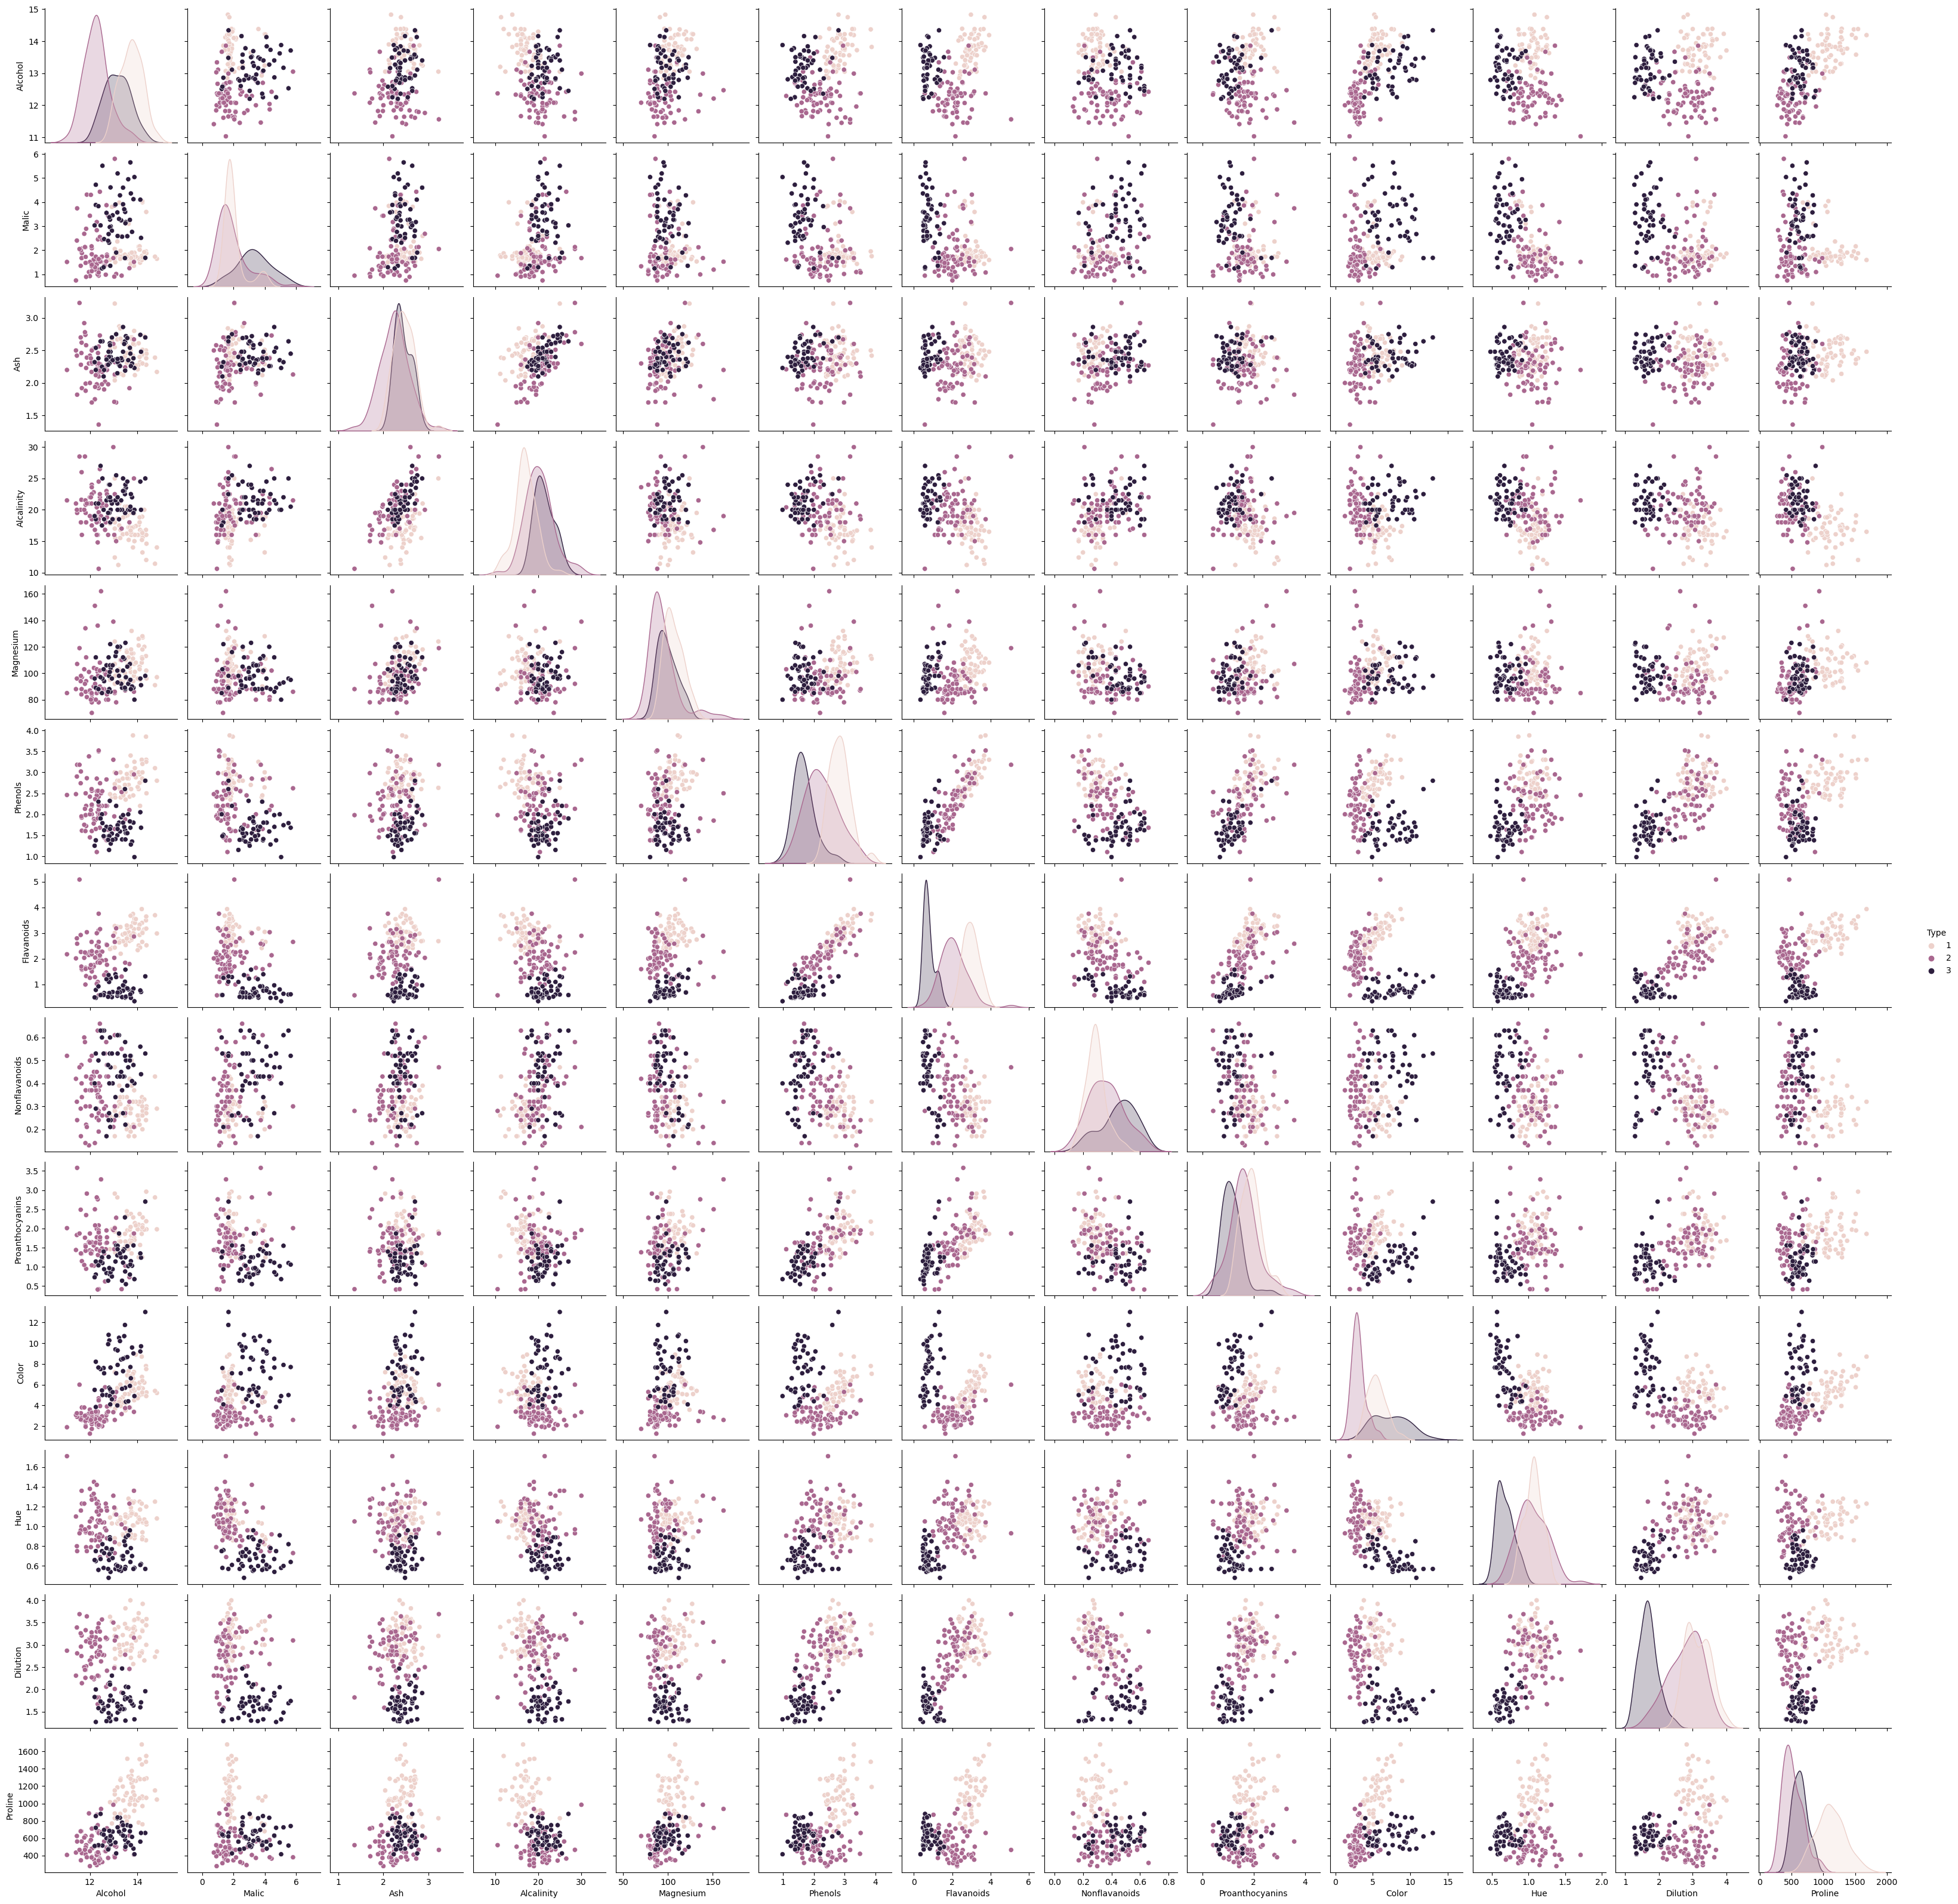

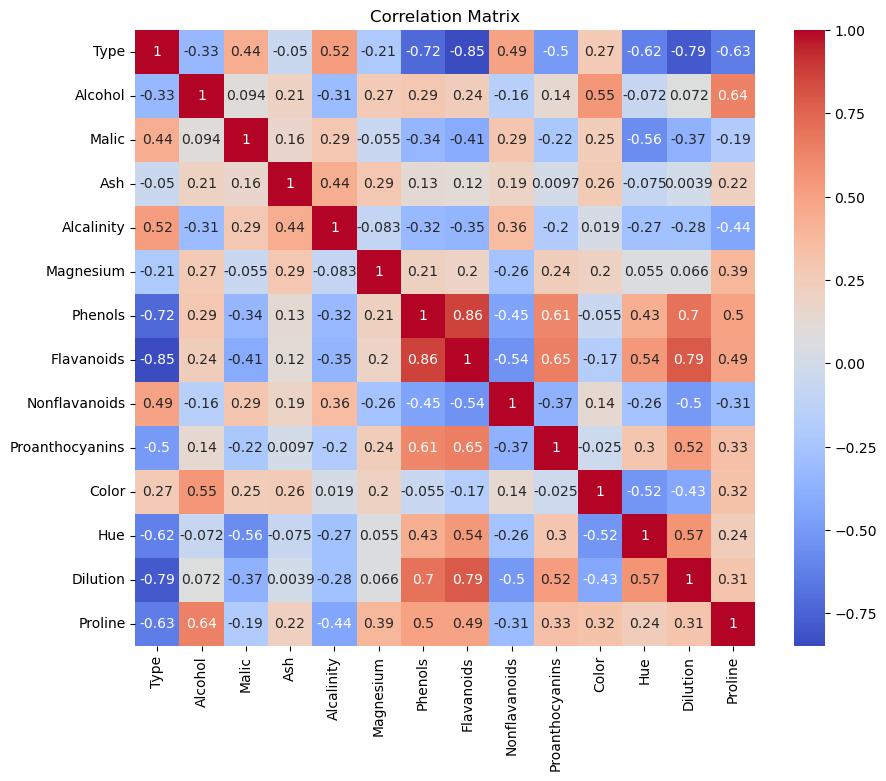

In [17]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [18]:
#K-Means Clustering on Original Data
# Elbow Method to find optimal clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


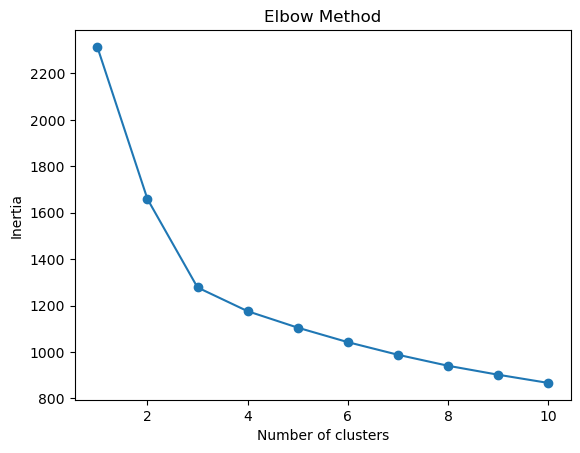

In [19]:
# Plotting Elbow Plot
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [20]:
# From the elbow plot, select optimal number of clusters, say k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Clusters_Original'] = kmeans.fit_predict(scaled_df)

In [21]:
# Silhouette Score for validation
score = silhouette_score(scaled_df, df['KMeans_Clusters_Original'])
print(f'Silhouette Score for K-Means on Original Data: {score}')

Silhouette Score for K-Means on Original Data: 0.28485891918989864


In [22]:
#Perform PCA Analysis
# Applying PCA
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_df)

In [23]:
# Convert the PCA results into a DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'])

In [24]:
# Explained variance
explained_variance = pca.explained_variance_ratio_
print(f'Explained Variance for each principal component: {explained_variance}')

Explained Variance for each principal component: [0.36198848 0.1920749  0.11123631]


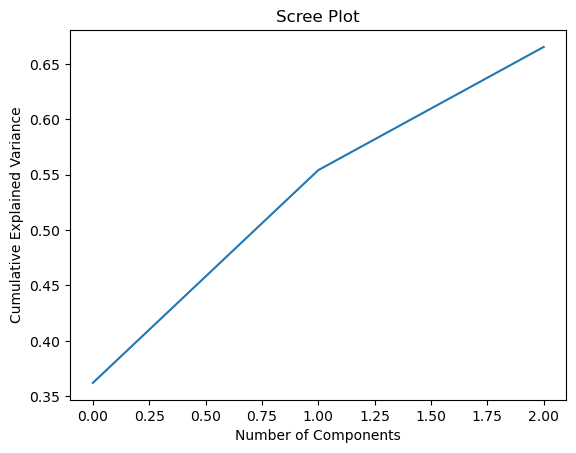

In [25]:
# Scree Plot to see variance explained by each component
plt.plot(np.cumsum(explained_variance))
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [26]:
#Clustering After PCA
#K-Means on PCA Transformed Data
# Elbow Method after PCA to find optimal clusters
inertia_pca = []
for k in range(1, 11):
    kmeans_pca = KMeans(n_clusters=k, random_state=42)
    kmeans_pca.fit(pca_df)
    inertia_pca.append(kmeans_pca.inertia_)

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


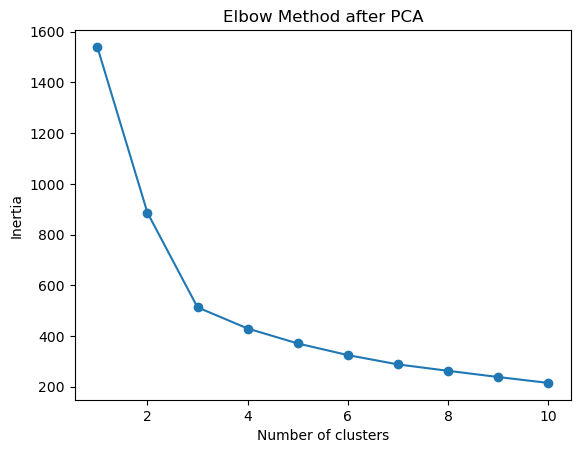

In [27]:
# Plotting Elbow Plot for PCA-transformed data
plt.plot(range(1, 11), inertia_pca, marker='o')
plt.title('Elbow Method after PCA')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [28]:
# Applying K-Means after PCA with optimal k (e.g., k=3)
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_df['KMeans_Clusters_PCA'] = kmeans_pca.fit_predict(pca_df)

In [29]:
# Silhouette Score for validation
score_pca = silhouette_score(pca_df[['PC1', 'PC2', 'PC3']], pca_df['KMeans_Clusters_PCA'])
print(f'Silhouette Score for K-Means on PCA-transformed Data: {score_pca}')

Silhouette Score for K-Means on PCA-transformed Data: 0.4537999848257617


In [30]:
#Hierarchical Clustering After PCA
# Perform Hierarchical clustering on PCA data
linkage_matrix = linkage(pca_df[['PC1', 'PC2', 'PC3']], method='ward')

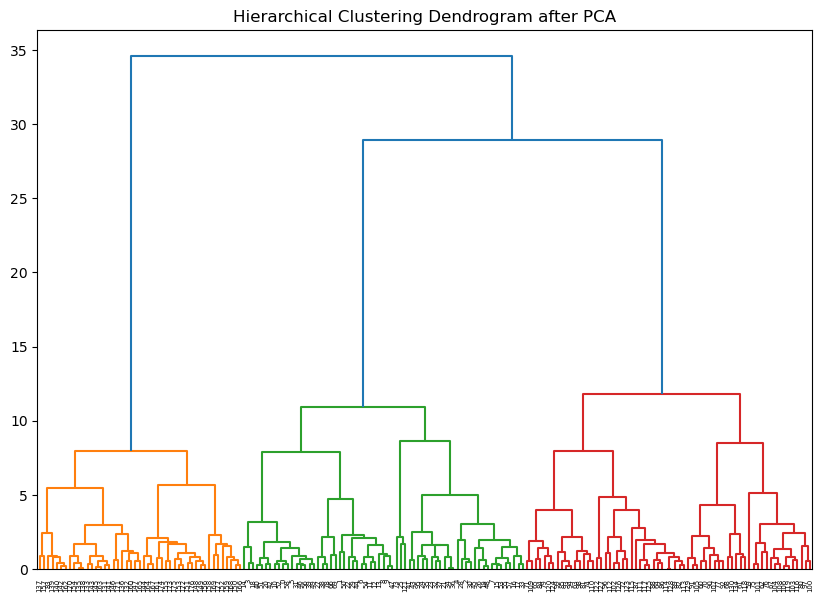

In [31]:
# Dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram after PCA')
plt.show()

In [32]:
# Compare cluster results
original_clusters = df['KMeans_Clusters_Original'].value_counts()
pca_clusters = pca_df['KMeans_Clusters_PCA'].value_counts()

In [33]:
print("Cluster counts before PCA: \n", original_clusters)
print("Cluster counts after PCA: \n", pca_clusters)

Cluster counts before PCA: 
 2    65
1    62
0    51
Name: KMeans_Clusters_Original, dtype: int64
Cluster counts after PCA: 
 2    65
1    62
0    51
Name: KMeans_Clusters_PCA, dtype: int64


Benefits/Impact of the Solution:

Improved model performance
Better interpretability,etc

# Problem Statement 2: -

A pharmaceuticals manufacturing company is conducting a study on a new medicine to treat heart diseases. The company has gathered data from its secondary sources and would like you to provide high level analytical insights on the data. Its aim is to segregate patients depending on their age group and other factors given in the data. Perform PCA and clustering algorithms on the dataset and check if the clusters formed before and after PCA are the same and provide a brief report on your model. You can also explore more ways to improve your model. 


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load dataset
df=pd.read_csv("F:/Data science/Assignments/PCA assignment/heart disease.csv")

In [4]:
#view some rows
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
#check shape of dataset 
df.shape

(303, 14)

In [6]:
#check datatype and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
#check null and print total no. of null 
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
#data preprocessing 
#drop row with missing values
df.dropna(inplace=True)

In [9]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('age', axis=1))  # Assuming 'age' is the target

In [10]:
# Convert the scaled data back to a DataFrame for clarity
scaled_df = pd.DataFrame(scaled_data, columns=df.columns[1:])

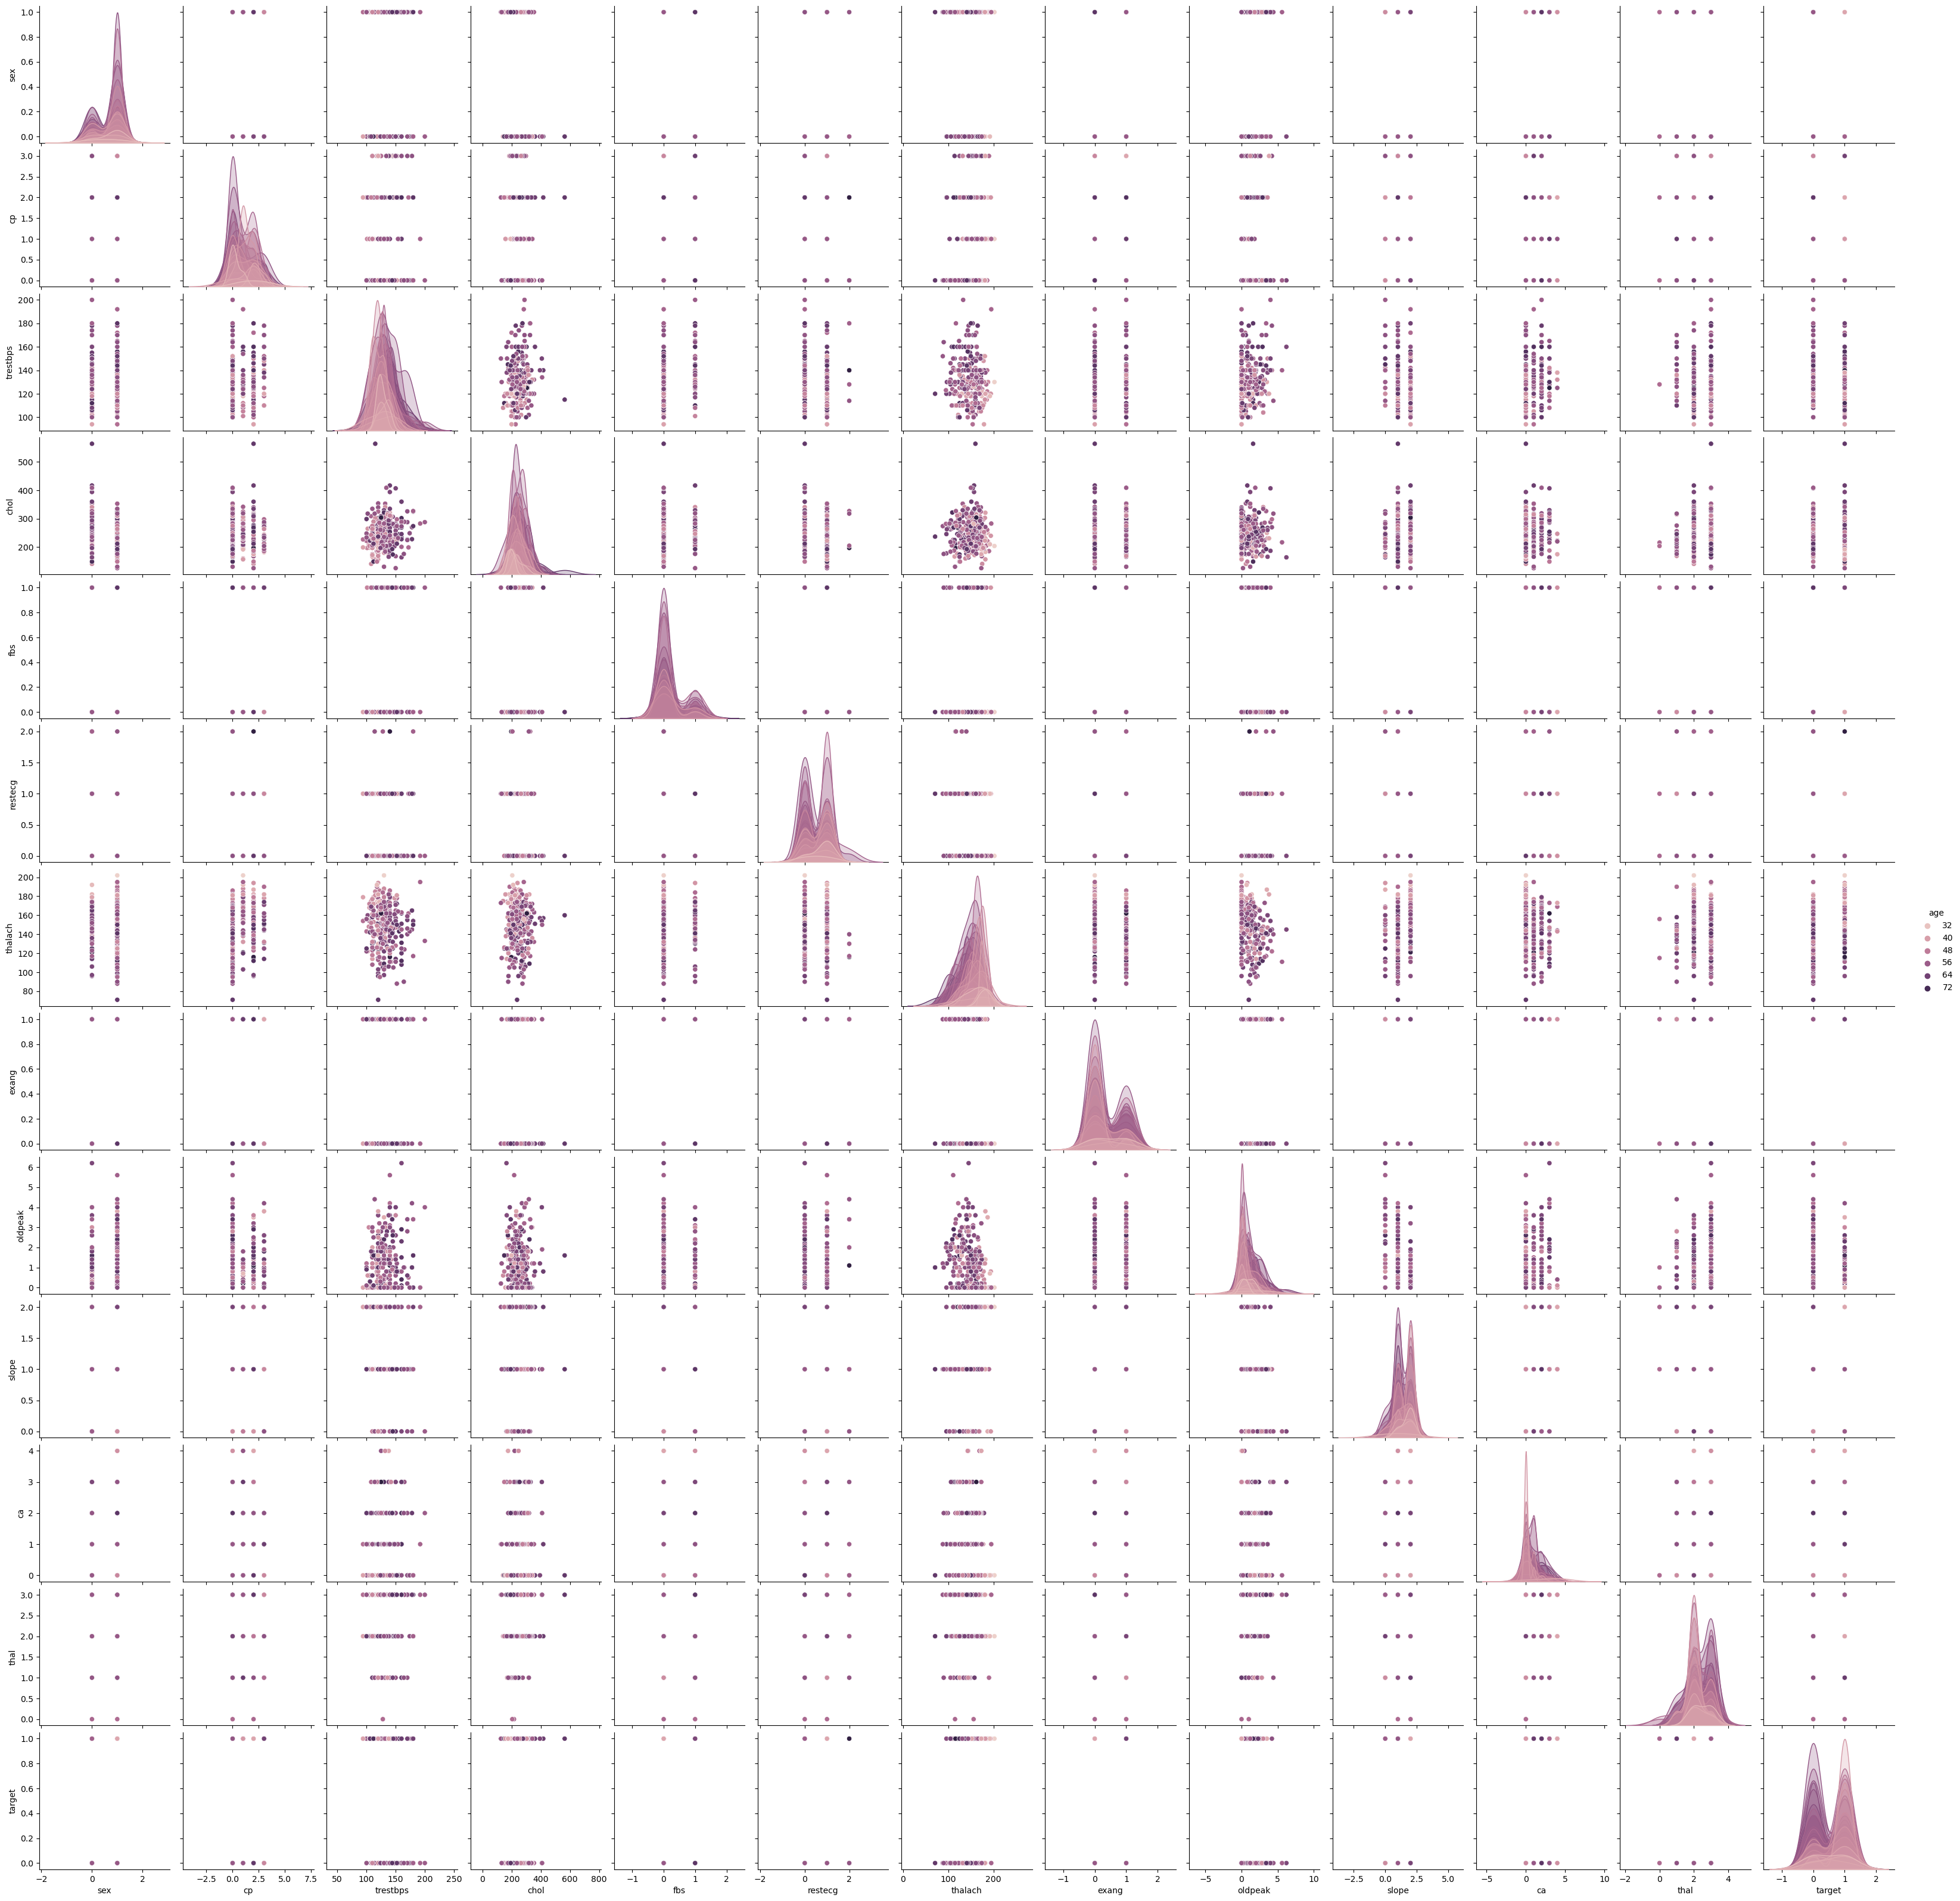

In [11]:
#EDA: Univariate and Bivariate Analysis
# Pairplot to see relationships
sns.pairplot(df, hue='age')

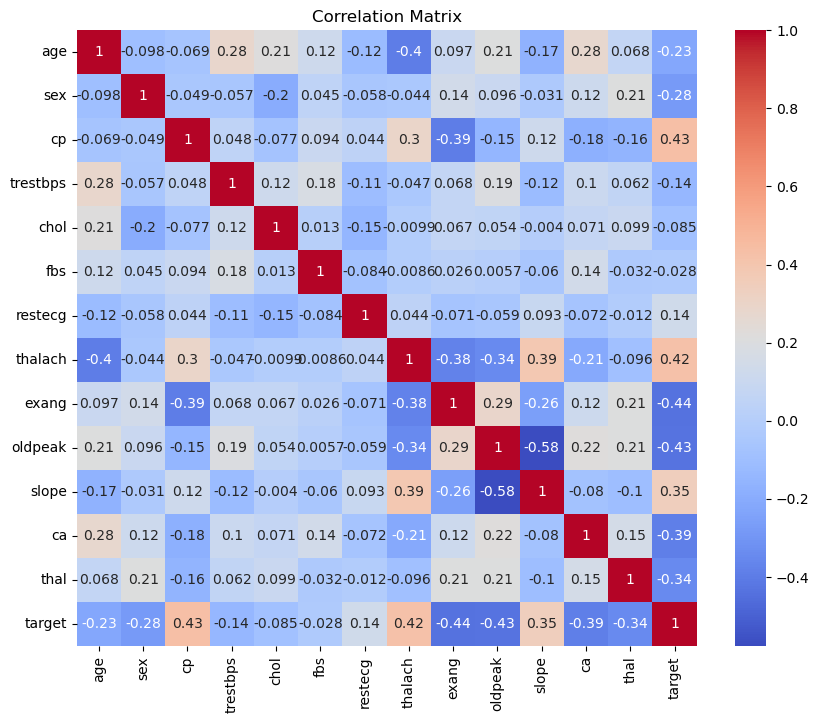

In [12]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [13]:
#K-Means Clustering on Original Data
# Elbow Method to find optimal clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


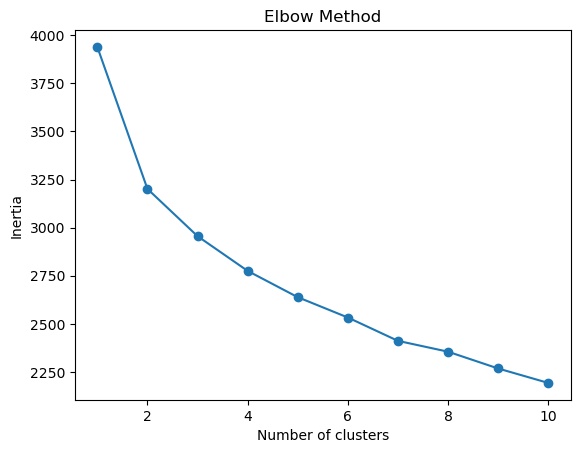

In [14]:
# Plotting Elbow Plot
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [15]:
# From the elbow plot, select optimal number of clusters, say k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Clusters_Original'] = kmeans.fit_predict(scaled_df)

In [16]:
# Silhouette Score for validation
score = silhouette_score(scaled_df, df['KMeans_Clusters_Original'])
print(f'Silhouette Score for K-Means on Original Data: {score}')

Silhouette Score for K-Means on Original Data: 0.12728787370103628


In [17]:
#Perform PCA Analysis
# Applying PCA
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_df)

In [18]:
# Convert the PCA results into a DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'])

In [19]:
# Explained variance
explained_variance = pca.explained_variance_ratio_
print(f'Explained Variance for each principal component: {explained_variance}')

Explained Variance for each principal component: [0.24222524 0.10712573 0.09446941]


In [20]:
#Clustering After PCA
#K-Means on PCA Transformed Data
# Elbow Method after PCA to find optimal clusters
inertia_pca = []
for k in range(1, 11):
    kmeans_pca = KMeans(n_clusters=k, random_state=42)
    kmeans_pca.fit(pca_df)
    inertia_pca.append(kmeans_pca.inertia_)

C:\Users\Sai\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [21]:
# Applying K-Means after PCA with optimal k (e.g., k=3)
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_df['KMeans_Clusters_PCA'] = kmeans_pca.fit_predict(pca_df)

In [22]:
# Silhouette Score for validation
score_pca = silhouette_score(pca_df[['PC1', 'PC2', 'PC3']], pca_df['KMeans_Clusters_PCA'])
print(f'Silhouette Score for K-Means on PCA-transformed Data: {score_pca}')

Silhouette Score for K-Means on PCA-transformed Data: 0.3033370955745366


In [23]:
#Hierarchical Clustering After PCA
# Perform Hierarchical clustering on PCA data
linkage_matrix = linkage(pca_df[['PC1', 'PC2', 'PC3']], method='ward')

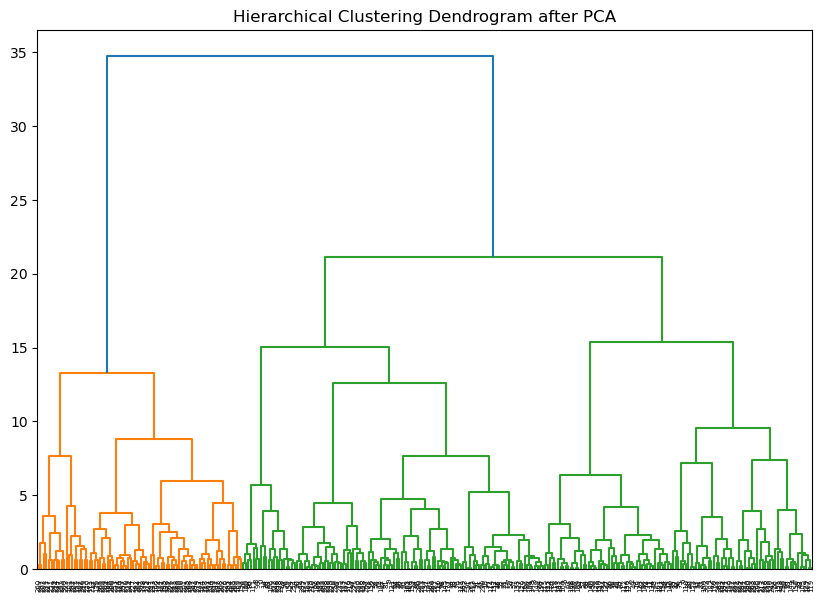

In [24]:
# Dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram after PCA')
plt.show()

In [25]:
# Compare cluster results
original_clusters = df['KMeans_Clusters_Original'].value_counts()
pca_clusters = pca_df['KMeans_Clusters_PCA'].value_counts()

In [26]:
print("Cluster counts before PCA: \n", original_clusters)
print("Cluster counts after PCA: \n", pca_clusters)

Cluster counts before PCA: 
 1    121
0    107
2     75
Name: KMeans_Clusters_Original, dtype: int64
Cluster counts after PCA: 
 2    110
0    108
1     85
Name: KMeans_Clusters_PCA, dtype: int64


# HomePrices.csv (apply PCA)

Business objectives: 

Reduce the dimensionality of the housing dataset (town, area, price) to identify key patterns and simplify data analysis using PCA.

In [26]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [27]:
df=pd.read_csv("F:/Data science/Assignments/PCA assignment/homeprices.csv")

In [28]:
df.head(5)

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000


In [29]:
df.shape

(13, 3)

In [30]:
df.isnull()

,town,area,price
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False
6,False,False,False
7,False,False,False
8,False,False,False
9,False,False,False


In [31]:
df.isnull().sum()

town     0
area     0
price    0
dtype: int64

In [32]:
#data preprocessing 
#drop row with missing values
df.dropna(inplace=True)

In [33]:
# Step 1: Handle categorical data (OneHotEncoding 'town')
# We use ColumnTransformer to apply OneHotEncoder to the 'town' column
preprocessor = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), ['town'])], remainder='passthrough')

In [34]:
# Step 2: Standardize the features
scaler = StandardScaler()

In [35]:
# Apply the preprocessor and scaler
X = preprocessor.fit_transform(df)
X_scaled = scaler.fit_transform(X)

In [36]:
# Step 3: Apply PCA
pca = PCA(n_components=2)  # Choosing 2 principal components for simplicity
X_pca = pca.fit_transform(X_scaled)

In [38]:
# Output results
print("PCA Components (Transformed Data):\n", X_pca)
print("Explained Variance Ratios:", pca.explained_variance_ratio_)

PCA Components (Transformed Data):
 [[-1.1646989  -1.85182201]
 [-0.37970946 -1.71628978]
 [ 0.43209616 -1.44501056]
 [ 1.83207493 -1.01099244]
 [ 2.95251309 -0.71264972]
 [-1.3987583   1.17168698]
 [-0.75467704  1.36156096]
 [ 0.40826114  1.61916526]
 [ 1.5421074   1.98538147]
 [-2.09285261 -0.16893367]
 [-1.3503632   0.00733697]
 [-0.81809818  0.14294079]
 [ 0.79210497  0.61762574]]
Explained Variance Ratios: [0.40511237 0.31097764]
